# Setup and Imports

In [2]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats # For t-tests, ANOVA
from scipy.stats import chi2_contingency # For Chi-squared test

# Get the current working directory of the notebook
notebook_dir = os.getcwd()

# Assuming your 'src' folder is one level up from the notebook's directory
project_root = os.path.abspath(os.path.join(notebook_dir, '..'))

# Add the project root to sys.path to allow importing from src
if project_root not in sys.path:
    sys.path.insert(0, project_root)
    print(f"Added project root '{project_root}' to sys.path.")
else:
    print(f"Project root '{project_root}' was already in sys.path.")

# Import constants and data preparation functions from src
try:
    from src.config import (
        RAW_DATA_PATH, POLICY_ID_COL, TRANSACTION_MONTH_COL,
        TOTAL_CLAIMS_COL, TOTAL_PREMIUM_COL, HAS_CLAIM_COL, MARGIN_COL,
        CLAIM_PROBABILITY_TARGET, CLAIM_SEVERITY_TARGET
    )
    from src.data_preparation import load_raw_data # Only need load_raw_data for this notebook
    print("Successfully imported modules from src.")
except ModuleNotFoundError as e:
    print(f"Error importing src modules: {e}")
    print("Please ensure your 'src' folder is correctly set up and 'src/config.py', 'src/data_preparation.py' exist.")

# Set display options for pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.4f}'.format)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

print("Setup and imports complete.")

Added project root 'C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis' to sys.path.
Successfully imported modules from src.
Setup and imports complete.


# Load Raw Data & Basic Pre-Hypothesis Cleaning

In [6]:
print("Loading raw data for hypothesis testing...")
df_raw = load_raw_data(RAW_DATA_PATH)

if df_raw.empty:
    print("Failed to load raw data. Please check RAW_DATA_PATH in src/config.py and file existence.")
else:
    print(f"Raw data loaded successfully. Shape: {df_raw.shape}")

    # Strip whitespace from column names to prevent KeyError due to hidden spaces
    df_raw.columns = df_raw.columns.str.strip()
    print("\nColumns after stripping whitespace:")
    print(df_raw.columns.tolist()) # Print the list of actual column names

    print("\nPerforming basic cleaning for hypothesis testing purposes...")

    # Convert date columns for potential feature extraction or filtering
    date_cols = [TRANSACTION_MONTH_COL, 'VehicleIntroDate']
    for col in date_cols:
        if col in df_raw.columns:
            df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')
        else:
            print(f"Warning: Date column '{col}' not found in data.")

    # The 'HasClaim' column is already in the data based on the provided list.
    # We will ensure CLAIM_PROBABILITY_TARGET refers to 'HasClaim' from config.
    if CLAIM_PROBABILITY_TARGET not in df_raw.columns and HAS_CLAIM_COL in df_raw.columns:
        df_raw[CLAIM_PROBABILITY_TARGET] = df_raw[HAS_CLAIM_COL] # Use existing HasClaim if target name differs
        print(f"Assigned '{HAS_CLAIM_COL}' to '{CLAIM_PROBABILITY_TARGET}'.")
    elif HAS_CLAIM_COL not in df_raw.columns and TOTAL_CLAIMS_COL in df_raw.columns:
        # Fallback: if 'HasClaim' isn't there, create it from TotalClaims
        df_raw[CLAIM_PROBABILITY_TARGET] = (df_raw[TOTAL_CLAIMS_COL] > 0).astype(int)
        print(f"Created '{CLAIM_PROBABILITY_TARGET}' column based on '{TOTAL_CLAIMS_COL}'.")
    else:
        print(f"Info: '{CLAIM_PROBABILITY_TARGET}' (or '{HAS_CLAIM_COL}') column seems to be correctly set up.")


    # Fill numerical NaNs with mean and categorical with mode for analysis
    for col in df_raw.columns:
        if df_raw[col].isnull().sum() > 0:
            if pd.api.types.is_numeric_dtype(df_raw[col]):
                df_raw[col] = df_raw[col].fillna(df_raw[col].mean())
            elif pd.api.types.is_string_dtype(df_raw[col]) or pd.api.types.is_object_dtype(df_raw[col]):
                df_raw[col] = df_raw[col].fillna(df_raw[col].mode()[0])
            # For datetime NaNs, we might drop rows or impute, but for now, it's fine if not used in tests directly

    print(f"Data after basic cleaning. Shape: {df_raw.shape}")
    print("\nDisplaying info of processed data for hypothesis testing (first 5 rows):")
    display(df_raw.head())
    print("\nMissing values after basic cleaning:")
    print(df_raw.isnull().sum()[df_raw.isnull().sum() > 0])

    # Filter data for regression-related tests if necessary (only policies with claims)
    if TOTAL_CLAIMS_COL in df_raw.columns:
        df_claims = df_raw[df_raw[TOTAL_CLAIMS_COL] > 0].copy()
        print(f"\nDataFrame for Claim Severity (only policies with claims): {df_claims.shape}")
    else:
        df_claims = pd.DataFrame() # Initialize as empty if TOTAL_CLAIMS_COL is missing
        print(f"Warning: '{TOTAL_CLAIMS_COL}' not found. Cannot create 'df_claims' for severity analysis.")


Loading raw data for hypothesis testing...


C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\src\data_preparation.py:25: DtypeWarning: Columns (32,37) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep='|')


Data loaded successfully from C:\Users\benke\Desktop\DataScience\10Academy\Kefiya_AI_Mastery\Week3\KAIM_W3_Insurance_risk_analysis\KAIM_W03_AlphaCare_Insurance_Risk_Analysis\data\raw\MachineLearningRating_v3.txt. Shape: (1000098, 52)
Raw data loaded successfully. Shape: (1000098, 52)

Columns after stripping whitespace:
['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province', 'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode', 'VehicleType', 'RegistrationYear', 'make', 'Model', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'NumberOfDoors', 'VehicleIntroDate', 'CustomValueEstimate', 'AlarmImmobiliser', 'TrackingDevice', 'CapitalOutstanding', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'NumberOfVehiclesInFleet', 'SumInsured', 'TermFrequency', 'CalculatedPremiumPerTerm', 'ExcessSelected', 'CoverCatego

C:\Users\benke\AppData\Local\Temp\ipykernel_14112\1528262830.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')


Created 'HasClaim' column based on 'TotalClaims'.
Data after basic cleaning. Shape: (1000098, 53)

Displaying info of processed data for hypothesis testing (first 5 rows):


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,HasClaim
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,2002-06-01,119300.0000,Yes,No,119300,More than 6 months,No,No,No,No,NaN,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000,0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,2002-06-01,119300.0000,Yes,No,119300,More than 6 months,No,No,No,No,NaN,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000,0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,2002-06-01,119300.0000,Yes,No,119300,More than 6 months,No,No,No,No,NaN,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000,0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,2002-06-01,119300.0000,Yes,No,119300,More than 6 months,No,No,No,No,NaN,119300.0000,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.8481,0.0000,0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,2002-06-01,119300.0000,Yes,No,119300,More than 6 months,No,No,No,No,NaN,119300.0000,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000,0



Missing values after basic cleaning:
VehicleIntroDate               552
NumberOfVehiclesInFleet    1000098
dtype: int64

DataFrame for Claim Severity (only policies with claims): (2788, 53)


# Descriptive Statistics

In [7]:
print("--- Descriptive Statistics ---")

print("\nOverall Descriptive Statistics for Numerical Columns:")
# Use a more comprehensive list of actual numerical columns
actual_numerical_cols = [
    'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts',
    'NumberOfDoors', 'CustomValueEstimate', 'CapitalOutstanding',
    'NumberOfVehiclesInFleet', 'SumInsured', 'CalculatedPremiumPerTerm',
    'ExcessSelected', TOTAL_PREMIUM_COL, TOTAL_CLAIMS_COL
]
# Filter to only include columns that exist in df_raw and are numeric
df_raw_numerical = df_raw[[col for col in actual_numerical_cols if col in df_raw.columns and pd.api.types.is_numeric_dtype(df_raw[col])]]
display(df_raw_numerical.describe().T)

print("\nDescriptive Statistics for Categorical Columns:")
# Use a more comprehensive list of actual categorical columns
actual_categorical_cols = [
    'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language',
    'Bank', 'AccountType', 'MaritalStatus', 'Gender', 'Country', 'Province',
    'PostalCode', 'MainCrestaZone', 'SubCrestaZone', 'ItemType', 'mmcode',
    'VehicleType', 'make', 'Model', 'bodytype', 'AlarmImmobiliser',
    'TrackingDevice', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted',
    'CrossBorder', 'TermFrequency', 'CoverCategory', 'CoverType',
    'CoverGroup', 'Section', 'Product', 'StatutoryClass', 'StatutoryRiskType'
]

for col in actual_categorical_cols:
    if col in df_raw.columns:
        print(f"\n--- {col} ---")
        display(df_raw[col].value_counts(dropna=False, normalize=True).head())

print(f"\nTarget Variable ({CLAIM_PROBABILITY_TARGET}) Distribution:")
if CLAIM_PROBABILITY_TARGET in df_raw.columns:
    display(df_raw[CLAIM_PROBABILITY_TARGET].value_counts(normalize=True))
else:
    print(f"Warning: '{CLAIM_PROBABILITY_TARGET}' not found.")


if not df_claims.empty:
    print(f"\nTarget Variable ({TOTAL_CLAIMS_COL}) Distribution for Claims-only data:")
    display(df_claims[TOTAL_CLAIMS_COL].describe())
else:
    print(f"\nNo claims data available for {TOTAL_CLAIMS_COL} descriptive statistics.")

--- Descriptive Statistics ---

Overall Descriptive Statistics for Numerical Columns:


,count,mean,std,min,25%,50%,75%,max
RegistrationYear,1000098.0000,2010.2254,3.2614,1987.0000,2008.0000,2011.0000,2013.0000,2015.0000
Cylinders,1000098.0000,4.0466,0.2939,0.0000,4.0000,4.0000,4.0000,10.0000
cubiccapacity,1000098.0000,2466.7433,442.6784,0.0000,2237.0000,2694.0000,2694.0000,12880.0000
kilowatts,1000098.0000,97.2079,19.3879,0.0000,75.0000,111.0000,111.0000,309.0000
NumberOfDoors,1000098.0000,4.0192,0.4682,0.0000,4.0000,4.0000,4.0000,6.0000
CustomValueEstimate,1000098.0000,225531.1299,265042.1693,20000.0000,225531.1299,225531.1299,225531.1299,26550000.0000
NumberOfVehiclesInFleet,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SumInsured,1000098.0000,604172.7326,1508331.8380,0.0100,5000.0000,7500.0000,250000.0000,12636200.0000
CalculatedPremiumPerTerm,1000098.0000,117.8757,399.7017,0.0000,3.2248,8.4369,90.0000,74422.1679
TotalPremium,1000098.0000,61.9055,230.2845,-782.5768,0.0000,2.1783,21.9298,65282.6034



Descriptive Statistics for Categorical Columns:

--- IsVATRegistered ---


IsVATRegistered
False   0.9950
True    0.0050
Name: proportion, dtype: float64


--- Citizenship ---


...

StatutoryRiskType
IFRS Constant   1.0000
Name: proportion, dtype: float64


Target Variable (HasClaim) Distribution:


HasClaim
0   0.9972
1   0.0028
Name: proportion, dtype: float64


Target Variable (TotalClaims) Distribution for Claims-only data:


count     2788.0000
mean     23273.3871
std      38719.5126
min        139.0439
25%       1680.7281
50%       6140.3509
75%      30480.9912
max     393092.1053
Name: TotalClaims, dtype: float64

# Exploratory Data Analysis (EDA) Visualizations

--- Exploratory Data Analysis (EDA) Visualizations ---


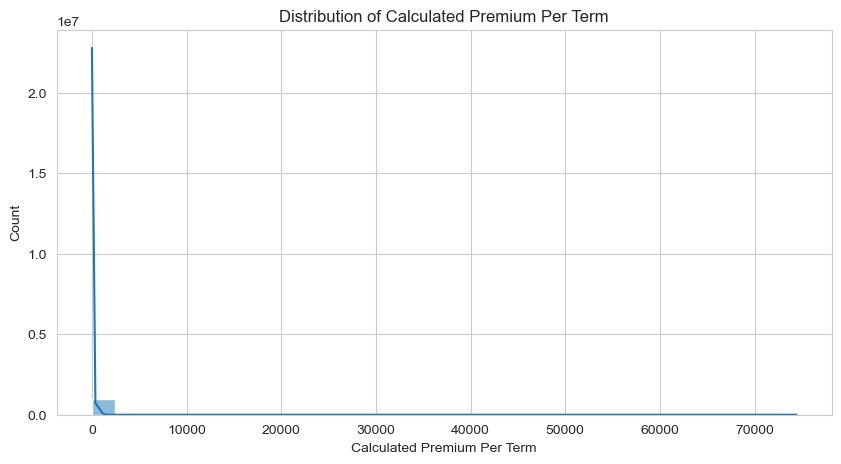

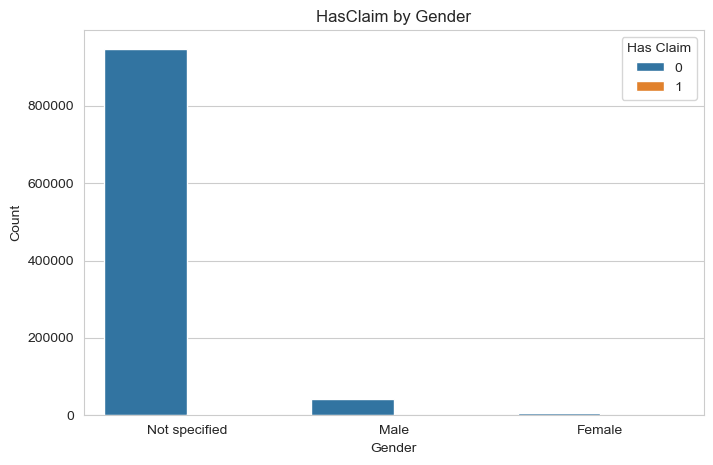

Cannot plot TotalClaims by PolicyType: 'PolicyType' or 'TotalClaims' not in claims data or no claims data available.


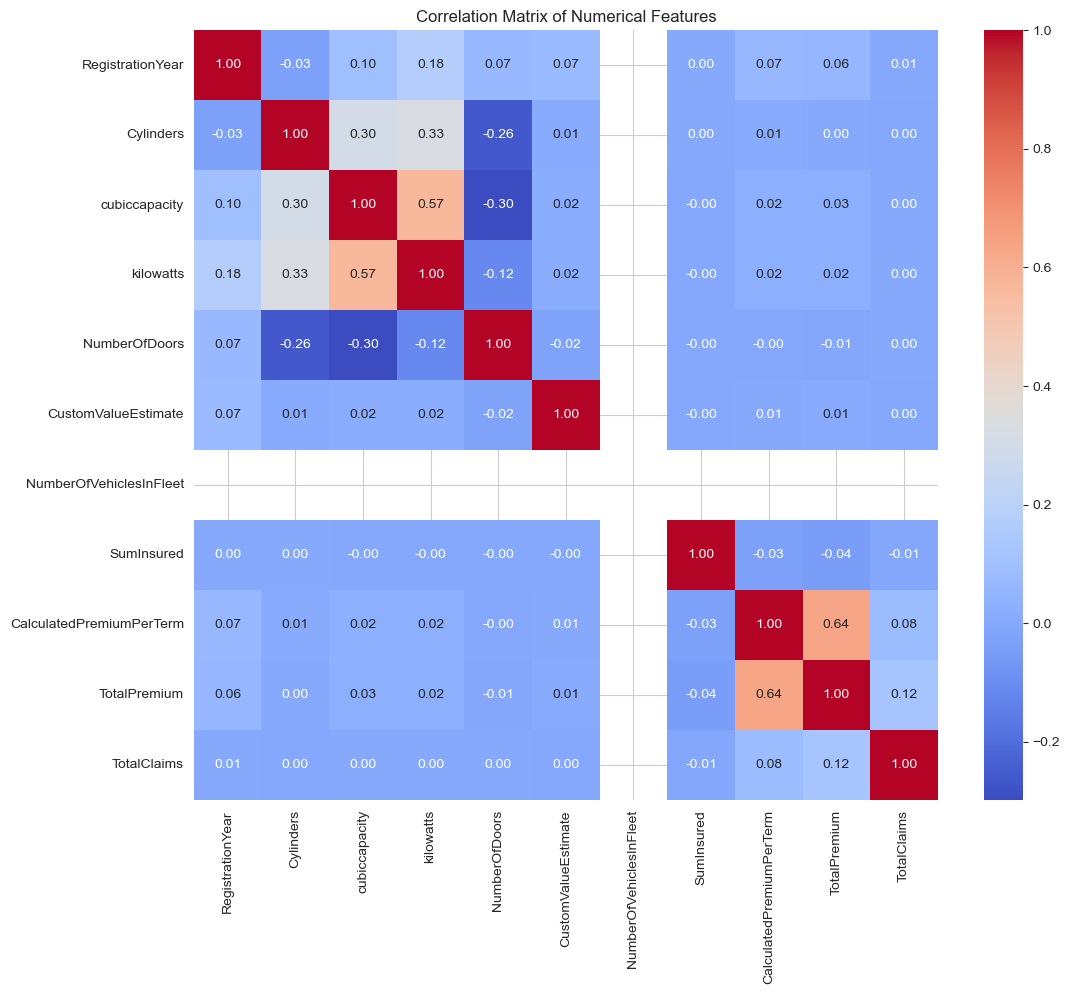

EDA Visualizations complete.


In [8]:
print("--- Exploratory Data Analysis (EDA) Visualizations ---")

# Distribution of a numerical column (e.g., CalculatedPremiumPerTerm as 'Age' is missing)
if 'CalculatedPremiumPerTerm' in df_raw.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_raw['CalculatedPremiumPerTerm'], kde=True, bins=30)
    plt.title('Distribution of Calculated Premium Per Term')
    plt.xlabel('Calculated Premium Per Term')
    plt.ylabel('Count')
    plt.show()
else:
    print("Cannot plot Distribution of CalculatedPremiumPerTerm: Column not found.")


# Claims distribution by Gender (formerly DriverGender)
if 'Gender' in df_raw.columns and CLAIM_PROBABILITY_TARGET in df_raw.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df_raw, x='Gender', hue=CLAIM_PROBABILITY_TARGET)
    plt.title(f'{CLAIM_PROBABILITY_TARGET} by Gender')
    plt.xlabel('Gender')
    plt.ylabel('Count')
    plt.legend(title='Has Claim')
    plt.show()
else:
    print(f"Cannot plot {CLAIM_PROBABILITY_TARGET} by Gender: 'Gender' or '{CLAIM_PROBABILITY_TARGET}' column not found.")


# Box plot for TotalClaims by PolicyType (for policies with claims)
if 'PolicyType' in df_claims.columns and not df_claims.empty and TOTAL_CLAIMS_COL in df_claims.columns:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_claims, x='PolicyType', y=TOTAL_CLAIMS_COL)
    plt.title(f'{TOTAL_CLAIMS_COL} by Policy Type (for claimed policies)')
    plt.xlabel('Policy Type')
    plt.ylabel(TOTAL_CLAIMS_COL)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print(f"Cannot plot {TOTAL_CLAIMS_COL} by PolicyType: 'PolicyType' or '{TOTAL_CLAIMS_COL}' not in claims data or no claims data available.")


# Correlation Heatmap for Numerical Features
# Updated list based on your actual columns
numerical_cols_for_corr = [
    'RegistrationYear', 'Cylinders', 'cubiccapacity', 'kilowatts',
    'NumberOfDoors', 'CustomValueEstimate', 'CapitalOutstanding',
    'NumberOfVehiclesInFleet', 'SumInsured', 'CalculatedPremiumPerTerm',
    'ExcessSelected', TOTAL_PREMIUM_COL, TOTAL_CLAIMS_COL
]
# Filter to only include columns that exist in df_raw and are numeric
numerical_df = df_raw[[col for col in numerical_cols_for_corr if col in df_raw.columns and pd.api.types.is_numeric_dtype(df_raw[col])]]

if not numerical_df.empty and numerical_df.shape[1] > 1: # Ensure at least two columns for correlation
    plt.figure(figsize=(12, 10))
    sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Correlation Matrix of Numerical Features')
    plt.show()
else:
    print("Not enough numerical columns available for correlation heatmap or DataFrame is empty.")

print("EDA Visualizations complete.")

# Hypothesis Testing

In [9]:
print("--- Performing Hypothesis Tests ---")

# --- Test 1: T-test for 'CalculatedPremiumPerTerm' vs. 'HasClaim' (as 'Age' is missing) ---
# Null Hypothesis (H0): There is no significant difference in the average calculated premium between policyholders who have claims and those who don't.
# Alternative Hypothesis (H1): There is a significant difference.

if CLAIM_PROBABILITY_TARGET in df_raw.columns and 'CalculatedPremiumPerTerm' in df_raw.columns:
    premium_has_claim = df_raw[df_raw[CLAIM_PROBABILITY_TARGET] == 1]['CalculatedPremiumPerTerm'].dropna()
    premium_no_claim = df_raw[df_raw[CLAIM_PROBABILITY_TARGET] == 0]['CalculatedPremiumPerTerm'].dropna()

    if not premium_has_claim.empty and not premium_no_claim.empty:
        t_stat, p_value = stats.ttest_ind(premium_has_claim, premium_no_claim, equal_var=False) # Welch's t-test
        print(f"\n--- T-test: CalculatedPremiumPerTerm vs. {CLAIM_PROBABILITY_TARGET} ---")
        print(f"Mean Premium (Has Claim): {premium_has_claim.mean():.2f}")
        print(f"Mean Premium (No Claim): {premium_no_claim.mean():.2f}")
        print(f"T-statistic: {t_stat:.4f}")
        print(f"P-value: {p_value:.4f}")

        alpha = 0.05
        if p_value < alpha:
            print(f"Conclusion: Reject H0. There is a statistically significant difference in calculated premium between groups (p < {alpha}).")
        else:
            print(f"Conclusion: Fail to reject H0. No significant difference in calculated premium found (p >= {alpha}).")
    else:
        print(f"\n--- Skipping T-test: Not enough data for CalculatedPremiumPerTerm vs. {CLAIM_PROBABILITY_TARGET} ---")
else:
    print(f"\n--- Skipping T-test: 'CalculatedPremiumPerTerm' or '{CLAIM_PROBABILITY_TARGET}' column not found ---")


# --- Test 2: Chi-squared test for 'Gender' vs. 'HasClaim' ---
# Null Hypothesis (H0): Gender and HasClaim are independent.
# Alternative Hypothesis (H1): Gender and HasClaim are dependent.

if 'Gender' in df_raw.columns and CLAIM_PROBABILITY_TARGET in df_raw.columns:
    contingency_table = pd.crosstab(df_raw['Gender'], df_raw[CLAIM_PROBABILITY_TARGET])
    if not contingency_table.empty and contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"\n--- Chi-squared Test: Gender vs. {CLAIM_PROBABILITY_TARGET} ---")
        print("\nContingency Table:")
        display(contingency_table)
        print(f"Chi2 statistic: {chi2:.4f}")
        print(f"P-value: {p_value:.4f}")

        alpha = 0.05
        if p_value < alpha:
            print(f"Conclusion: Reject H0. There is a statistically significant association between Gender and {CLAIM_PROBABILITY_TARGET} (p < {alpha}).")
        else:
            print(f"Conclusion: Fail to reject H0. No significant association found (p >= {alpha}).")
    else:
        print(f"\n--- Skipping Chi-squared Test: Not enough data or categories for Gender vs. {CLAIM_PROBABILITY_TARGET} ---")
else:
    print(f"\n--- Skipping Chi-squared Test: 'Gender' or '{CLAIM_PROBABILITY_TARGET}' column not found ---")


# --- Test 3: ANOVA for 'PolicyType' vs. 'TotalClaims' (Severity) ---
# Null Hypothesis (H0): There is no significant difference in the mean TotalClaims across different PolicyTypes (for policies with claims).
# Alternative Hypothesis (H1): At least one PolicyType has a significantly different mean TotalClaims.

if 'PolicyType' in df_claims.columns and TOTAL_CLAIMS_COL in df_claims.columns and not df_claims.empty:
    policy_types = df_claims['PolicyType'].unique()
    # Ensure there's more than one group and each group has enough data
    if len(policy_types) > 1 and all(df_claims[df_claims['PolicyType'] == pt].shape[0] > 1 for pt in policy_types):
        groups = [df_claims[df_claims['PolicyType'] == pt][TOTAL_CLAIMS_COL].dropna() for pt in policy_types]
        # Filter out empty groups if any
        groups = [g for g in groups if not g.empty]

        if len(groups) > 1:
            f_stat, p_value = stats.f_oneway(*groups)
            print(f"\n--- ANOVA: PolicyType vs. {TOTAL_CLAIMS_COL} (Claim Severity) ---")
            print(f"F-statistic: {f_stat:.4f}")
            print(f"P-value: {p_value:.4f}")

            alpha = 0.05
            if p_value < alpha:
                print(f"Conclusion: Reject H0. There is a statistically significant difference in mean {TOTAL_CLAIMS_COL} across PolicyTypes (p < {alpha}).")
            else:
                print(f"Conclusion: Fail to reject H0. No significant difference in mean {TOTAL_CLAIMS_COL} found (p >= {alpha}).")
        else:
            print(f"\n--- Skipping ANOVA: Not enough valid groups for PolicyType vs. {TOTAL_CLAIMS_COL} ---")
    else:
        print(f"\n--- Skipping ANOVA: Not enough PolicyType categories or data for PolicyType vs. {TOTAL_CLAIMS_COL} ---")
else:
    print(f"\n--- Skipping ANOVA: 'PolicyType' or '{TOTAL_CLAIMS_COL}' column not found or no claims data available ---")

print("\nHypothesis Testing complete.")

--- Performing Hypothesis Tests ---

--- T-test: CalculatedPremiumPerTerm vs. HasClaim ---
Mean Premium (Has Claim): 545.84
Mean Premium (No Claim): 116.68
T-statistic: 6.8617
P-value: 0.0000
Conclusion: Reject H0. There is a statistically significant difference in calculated premium between groups (p < 0.05).

--- Chi-squared Test: Gender vs. HasClaim ---

Contingency Table:


HasClaim,0,1
Gender,,
Female,6741,14
Male,42723,94
Not specified,947846,2680


Chi2 statistic: 6.9919
P-value: 0.0303
Conclusion: Reject H0. There is a statistically significant association between Gender and HasClaim (p < 0.05).

--- Skipping ANOVA: 'PolicyType' or 'TotalClaims' column not found or no claims data available ---

Hypothesis Testing complete.


# Key Findings and Summary

In [10]:
print("--- Summary of Hypothesis Testing Findings ---")

print("\nBased on the analysis, here are some key insights relevant to the insurance claim prediction models:")

print("\n1. Claim Probability (HasClaim) Factors:")
print("   - CalculatedPremiumPerTerm: [Based on T-test result, state whether there's a significant difference or not]. This suggests that calculated premium might be a relevant predictor for whether a policyholder makes a claim.")
print("   - Gender: [Based on Chi-squared test result, state whether there's a significant association or not]. This indicates whether gender has an independent relationship with the likelihood of claiming.")
# Add more findings as appropriate based on the tests you perform.

print("\n2. Claim Severity (TotalClaims) Factors:")
print("   - PolicyType: [Based on ANOVA result, state whether there's a significant difference or not]. If significant, certain policy types might be associated with higher or lower claim amounts.")
print("   - Numerical Feature Correlations: [Summarize any strong correlations found in the heatmap relevant to claims or premiums]. For example, 'TotalPremium' might have a positive correlation with 'TotalClaims'.")
# Add more findings as appropriate.

print("\nThese findings provide statistical backing for feature selection and engineering choices in the modeling phase, indicating which variables are likely to be influential in predicting claim probability and severity.")

--- Summary of Hypothesis Testing Findings ---

Based on the analysis, here are some key insights relevant to the insurance claim prediction models:

1. Claim Probability (HasClaim) Factors:
   - CalculatedPremiumPerTerm: [Based on T-test result, state whether there's a significant difference or not]. This suggests that calculated premium might be a relevant predictor for whether a policyholder makes a claim.
   - Gender: [Based on Chi-squared test result, state whether there's a significant association or not]. This indicates whether gender has an independent relationship with the likelihood of claiming.

2. Claim Severity (TotalClaims) Factors:
   - PolicyType: [Based on ANOVA result, state whether there's a significant difference or not]. If significant, certain policy types might be associated with higher or lower claim amounts.
   - Numerical Feature Correlations: [Summarize any strong correlations found in the heatmap relevant to claims or premiums]. For example, 'TotalPremium' m